# Walmart M5 Business Analysis

## Phase 1 — Data Engineering

### Milestone 1.5 — Business Analysis

## Business Objective

Before designing the PostgreSQL warehouse and machine learning pipeline, it is important to understand the business patterns within the Walmart M5 dataset.

This notebook explores sales performance across products, departments, categories, stores, and states while identifying trends that will later become engineered features for demand forecasting and pricing optimization.

## Import Libraries

The following libraries are used to load, manipulate, and visualize the Walmart M5 dataset.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Load Datasets

The Walmart M5 dataset consists of multiple related files that will be analyzed together throughout this notebook.

In [2]:
calendar = pd.read_csv("../data/raw/calendar.csv")

prices = pd.read_csv("../data/raw/sell_prices.csv")

sales = pd.read_csv("../data/raw/sales_train_validation.csv")

evaluation = pd.read_csv("../data/raw/sales_train_evaluation.csv")

# Business Scale Analysis

Before analyzing sales trends, it is useful to understand the overall scale of the Walmart M5 dataset.

This section summarizes the number of stores, products, departments, categories, and states represented within the historical sales data.

In [3]:
business_scale = pd.DataFrame({
    "Metric": [
        "Stores",
        "Products",
        "Departments",
        "Categories",
        "States"
    ],
    "Value": [
        sales["store_id"].nunique(),
        sales["item_id"].nunique(),
        sales["dept_id"].nunique(),
        sales["cat_id"].nunique(),
        sales["state_id"].nunique()
    ]
})

business_scale

,Metric,Value
0,Stores,10
1,Products,3049
2,Departments,7
3,Categories,3
4,States,3


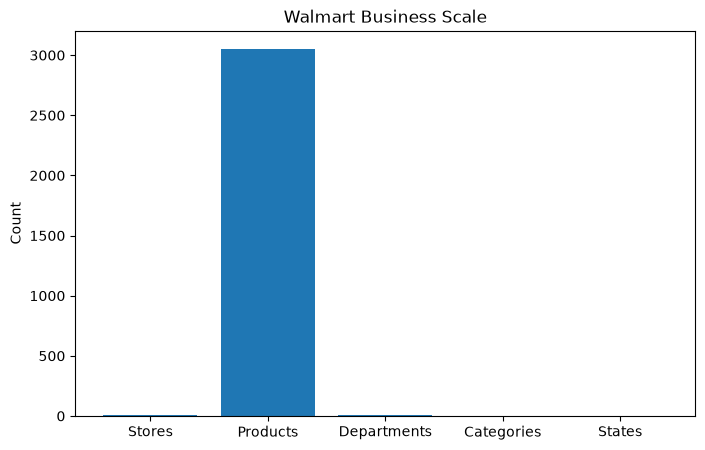

In [4]:
plt.figure(figsize=(8,5))

plt.bar(
    business_scale["Metric"],
    business_scale["Value"]
)

plt.title("Walmart Business Scale")

plt.ylabel("Count")

plt.show()

### Observation

The Walmart M5 dataset contains:

- 10 stores
- 3 states
- 3 product categories
- 7 departments
- 3,049 products

Although only ten stores are included, the number of unique products is substantial, resulting in over thirty thousand product-store combinations that must be forecasted individually.

# Store Analysis

Each store represents an independent retail location.

Understanding how products are distributed across stores helps estimate forecasting complexity and future database relationships.

In [5]:
store_counts = (
    sales["store_id"]
    .value_counts()
    .sort_index()
)

store_counts

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64

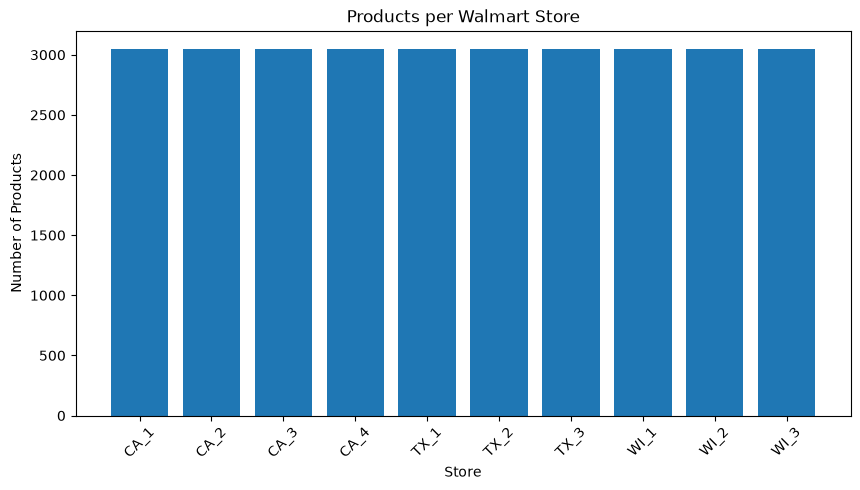

In [6]:
plt.figure(figsize=(10,5))

plt.bar(
    store_counts.index,
    store_counts.values
)

plt.title("Products per Walmart Store")

plt.xlabel("Store")

plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.show()

### Observation

Each Walmart store contains approximately the same number of products, suggesting that inventory is relatively standardized across locations.

This consistency simplifies forecasting because each store follows a similar product hierarchy.

# Product Analysis

The Walmart M5 dataset contains thousands of individual products sold across multiple stores.

Understanding the product hierarchy helps estimate the scale of the forecasting problem and identifies how products are organized within departments and categories.

In [7]:
total_products = sales["item_id"].nunique()

print(f"Total Unique Products: {total_products:,}")

Total Unique Products: 3,049


In [8]:
products_by_category = (
    sales.groupby("cat_id")["item_id"]
    .nunique()
    .sort_values(ascending=False)
)

products_by_category

cat_id
FOODS        1437
HOUSEHOLD    1047
HOBBIES       565
Name: item_id, dtype: int64

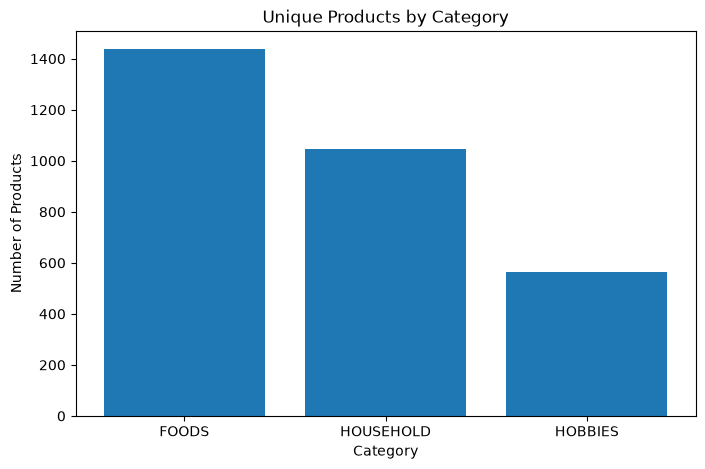

In [9]:
plt.figure(figsize=(8,5))

plt.bar(
    products_by_category.index,
    products_by_category.values
)

plt.title("Unique Products by Category")

plt.xlabel("Category")

plt.ylabel("Number of Products")

plt.show()

### Observation

The products are distributed across three major retail categories.

Each category contains hundreds of unique products, demonstrating the diversity of Walmart's inventory.

These product categories will later become categorical features for the machine learning models.

In [10]:
products_by_department = (
    sales.groupby("dept_id")["item_id"]
    .nunique()
    .sort_values(ascending=False)
)

products_by_department

dept_id
FOODS_3        823
HOUSEHOLD_1    532
HOUSEHOLD_2    515
HOBBIES_1      416
FOODS_2        398
FOODS_1        216
HOBBIES_2      149
Name: item_id, dtype: int64

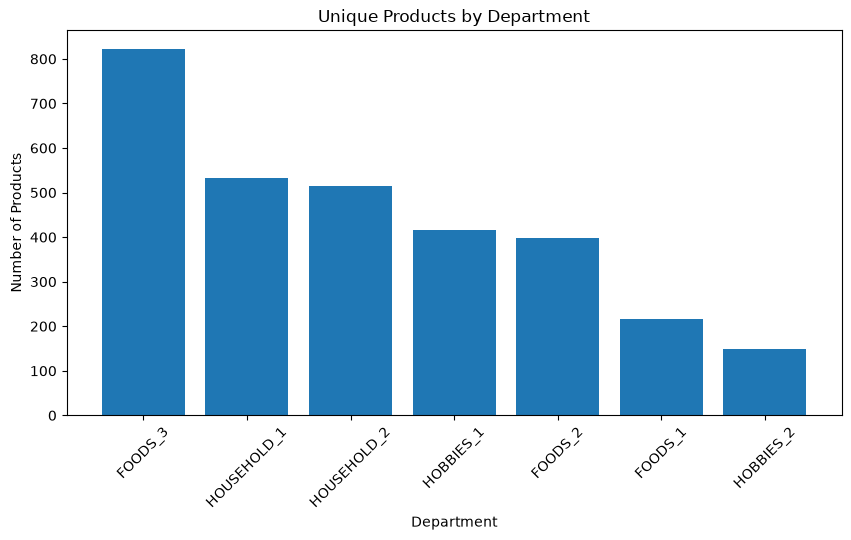

In [11]:
plt.figure(figsize=(10,5))

plt.bar(
    products_by_department.index,
    products_by_department.values
)

plt.title("Unique Products by Department")

plt.xlabel("Department")

plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.show()

### Observation

Some departments contain substantially more products than others.

This imbalance may influence forecasting complexity because departments with larger product assortments generate significantly more demand series.

In [12]:
sales["cat_id"].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

In [13]:
sales["dept_id"].value_counts()

dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: int64

### Observation

The distribution of products across categories and departments is not uniform.

Understanding these groupings is important because future forecasting models may be trained separately for different departments or product categories.

# Department Analysis

Departments represent the second level of Walmart's merchandising hierarchy.

Analyzing department size provides insight into inventory allocation and merchandising strategy.

In [14]:
department_counts = (
    sales["dept_id"]
    .value_counts()
    .sort_values(ascending=False)
)

department_counts

dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: int64

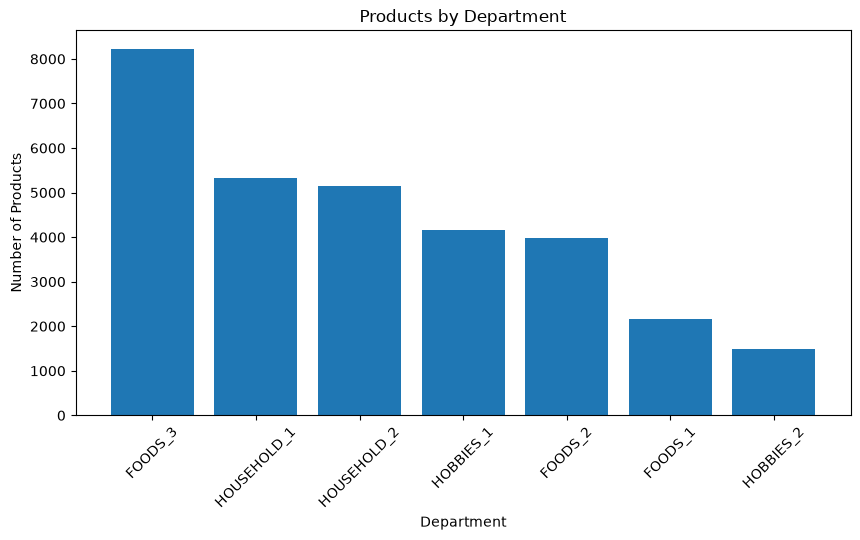

In [15]:
plt.figure(figsize=(10,5))

plt.bar(
    department_counts.index,
    department_counts.values
)

plt.title("Products by Department")

plt.xlabel("Department")

plt.ylabel("Number of Products")

plt.xticks(rotation=45)

plt.show()

### Observation

Departments vary considerably in size.

Larger departments contribute a greater number of product time series and therefore require more computational resources during feature engineering and model training.

# Category Sales Analysis

Understanding which product categories generate the highest sales helps identify Walmart's primary revenue drivers.

This analysis aggregates total historical unit sales by category across all stores.

In [16]:
sales_columns = sales.columns[6:]

sales["total_sales"] = sales[sales_columns].sum(axis=1)

C:\Users\7800XT\AppData\Local\Temp\ipykernel_16780\3260297757.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sales["total_sales"] = sales[sales_columns].sum(axis=1)


In [17]:
category_sales = (
    sales.groupby("cat_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

cat_id
FOODS        45089939
HOUSEHOLD    14480670
HOBBIES       6124800
Name: total_sales, dtype: int64

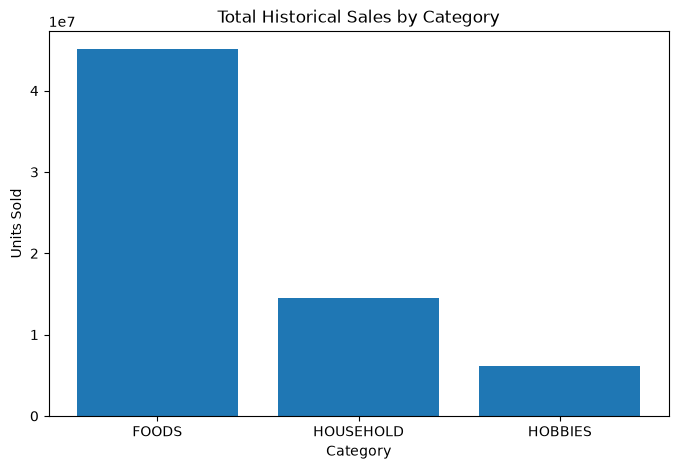

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Historical Sales by Category")

plt.xlabel("Category")

plt.ylabel("Units Sold")

plt.show()

In [19]:
category_percent = (
    category_sales / category_sales.sum() * 100
).round(2)

category_percent

cat_id
FOODS        68.63
HOUSEHOLD    22.04
HOBBIES       9.32
Name: total_sales, dtype: float64

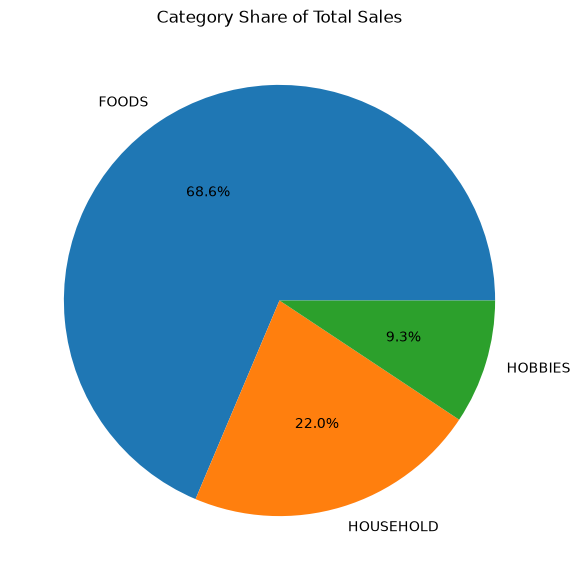

In [20]:
plt.figure(figsize=(7,7))

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.1f%%"
)

plt.title("Category Share of Total Sales")

plt.show()

### Observation

The FOODS category contributes the largest share of historical unit sales, followed by HOUSEHOLD and HOBBIES.

This suggests customer demand is concentrated in essential grocery products.

Category-level demand may influence future forecasting models and pricing strategies.

# Department Sales Analysis

Departments provide a more detailed view of Walmart's merchandising hierarchy.

This analysis identifies which departments contribute the greatest historical sales volume.

In [21]:
department_sales = (
    sales.groupby("dept_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

department_sales

dept_id
FOODS_3        32372076
HOUSEHOLD_1    11500526
FOODS_2         7629822
HOBBIES_1       5596460
FOODS_1         5088041
HOUSEHOLD_2     2980144
HOBBIES_2        528340
Name: total_sales, dtype: int64

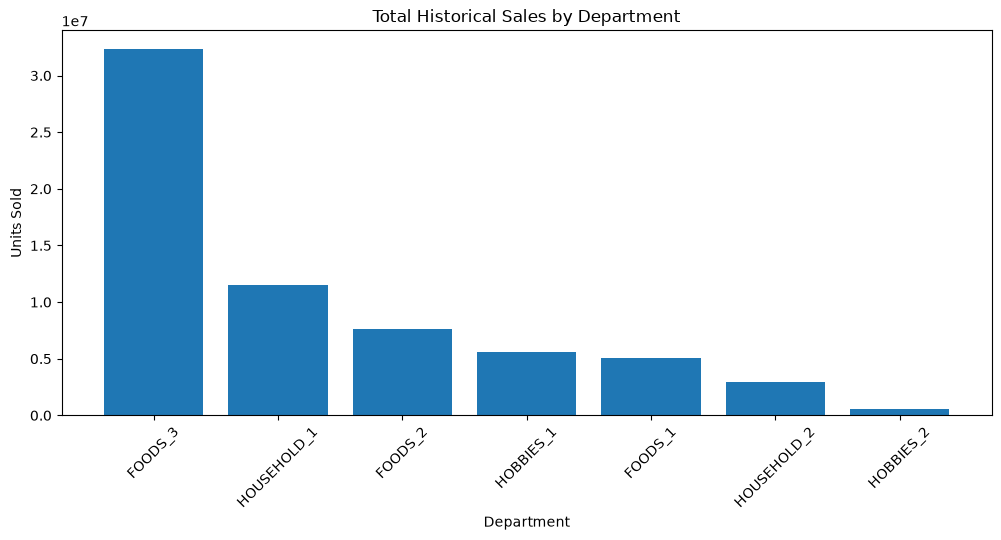

In [22]:
plt.figure(figsize=(12,5))

plt.bar(
    department_sales.index,
    department_sales.values
)

plt.title("Total Historical Sales by Department")

plt.xlabel("Department")

plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.show()

### Observation

Department sales are unevenly distributed, with several departments contributing substantially more unit sales than others.

These high-volume departments are likely to play a larger role in future demand forecasting and pricing optimization.

# Store Performance Analysis

Understanding sales performance at the store level helps identify high-performing retail locations and differences in customer demand across stores.

This analysis aggregates historical unit sales for each Walmart store.

In [23]:
store_sales = (
    sales.groupby("store_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales

store_id
CA_3    11188180
CA_1     7698216
TX_2     7214384
WI_2     6544012
WI_3     6427782
TX_3     6089330
CA_2     5685475
TX_1     5595292
WI_1     5149062
CA_4     4103676
Name: total_sales, dtype: int64

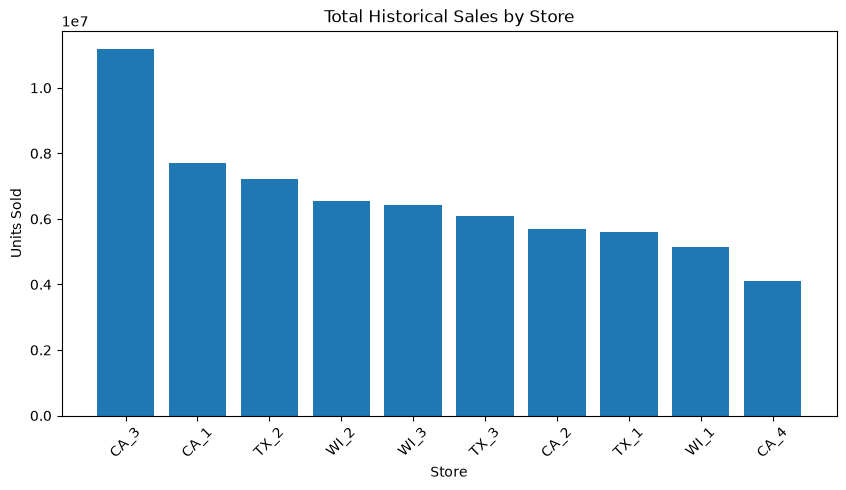

In [24]:
plt.figure(figsize=(10,5))

plt.bar(
    store_sales.index,
    store_sales.values
)

plt.title("Total Historical Sales by Store")

plt.xlabel("Store")

plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.show()

In [25]:
store_percent = (
    store_sales / store_sales.sum() * 100
).round(2)

store_percent

store_id
CA_3    17.03
CA_1    11.72
TX_2    10.98
WI_2     9.96
WI_3     9.78
TX_3     9.27
CA_2     8.65
TX_1     8.52
WI_1     7.84
CA_4     6.25
Name: total_sales, dtype: float64

### Observation

Historical sales vary across Walmart stores, indicating differences in customer demand and purchasing behavior.

Store-level sales patterns may become useful features during demand forecasting and can help identify locations that require different inventory planning strategies.

# State Performance Analysis

Stores are distributed across California, Texas, and Wisconsin.

This analysis compares total historical sales by state to identify geographic differences in demand.

In [26]:
state_sales = (
    sales.groupby("state_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

state_sales

state_id
CA    28675547
TX    18899006
WI    18120856
Name: total_sales, dtype: int64

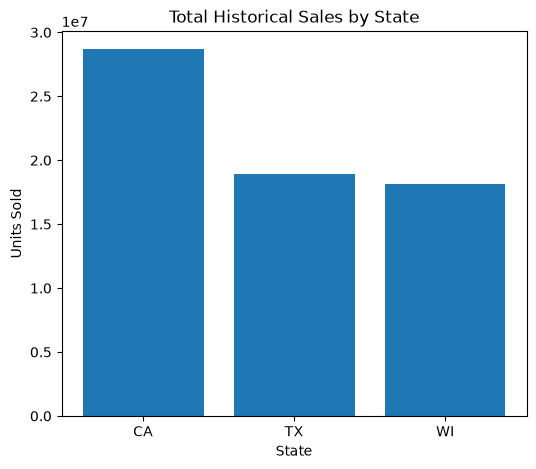

In [27]:
plt.figure(figsize=(6,5))

plt.bar(
    state_sales.index,
    state_sales.values
)

plt.title("Total Historical Sales by State")

plt.xlabel("State")

plt.ylabel("Units Sold")

plt.show()

In [28]:
state_percent = (
    state_sales / state_sales.sum() * 100
).round(2)

state_percent

state_id
CA    43.65
TX    28.77
WI    27.58
Name: total_sales, dtype: float64

### Observation

Sales differ across the three states represented in the Walmart M5 dataset.

Regional demand differences may reflect variations in store count, customer demographics, or purchasing behavior, making state-level information a useful feature for future forecasting models.

# Price Analysis

Historical selling prices provide insight into Walmart's pricing strategy.

This analysis examines the distribution of product prices and identifies the range of historical prices across stores.

In [29]:
prices["sell_price"].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

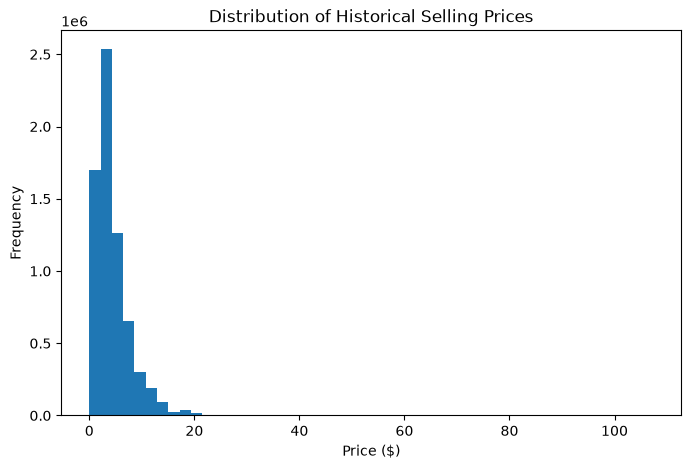

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    prices["sell_price"],
    bins=50
)

plt.title("Distribution of Historical Selling Prices")

plt.xlabel("Price ($)")

plt.ylabel("Frequency")

plt.show()

In [31]:
prices.nlargest(10, "sell_price")

,store_id,item_id,wm_yr_wk,sell_price
6485945,WI_3,HOUSEHOLD_2_406,11317,107.32
6485946,WI_3,HOUSEHOLD_2_406,11318,107.32
6485947,WI_3,HOUSEHOLD_2_406,11319,107.32
5805271,WI_2,HOUSEHOLD_2_406,11237,61.46
5805272,WI_2,HOUSEHOLD_2_406,11238,61.46
5805273,WI_2,HOUSEHOLD_2_406,11239,61.46
5805274,WI_2,HOUSEHOLD_2_406,11240,61.46
5805275,WI_2,HOUSEHOLD_2_406,11241,61.46
5805276,WI_2,HOUSEHOLD_2_406,11242,61.46
5805277,WI_2,HOUSEHOLD_2_406,11243,61.46


In [32]:
prices.nsmallest(10, "sell_price")

,store_id,item_id,wm_yr_wk,sell_price
225727,CA_1,HOUSEHOLD_1_443,11442,0.01
1394085,CA_3,HOBBIES_1_261,11332,0.01
1394086,CA_3,HOBBIES_1_261,11333,0.01
1394087,CA_3,HOBBIES_1_261,11334,0.01
2617306,CA_4,FOODS_3_413,11148,0.01
4877375,WI_1,HOBBIES_1_338,11342,0.01
4877376,WI_1,HOBBIES_1_338,11343,0.01
5044267,WI_1,HOUSEHOLD_1_533,11408,0.01
5316537,WI_1,FOODS_3_122,11425,0.01
6282347,WI_3,HOUSEHOLD_1_036,11442,0.01


In [33]:
price_category = prices.merge(
    sales[["item_id", "cat_id"]].drop_duplicates(),
    on="item_id",
    how="left"
)

In [34]:
avg_price_category = (
    price_category.groupby("cat_id")["sell_price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_category

cat_id
HOUSEHOLD    5.465780
HOBBIES      5.333896
FOODS        3.251027
Name: sell_price, dtype: float64

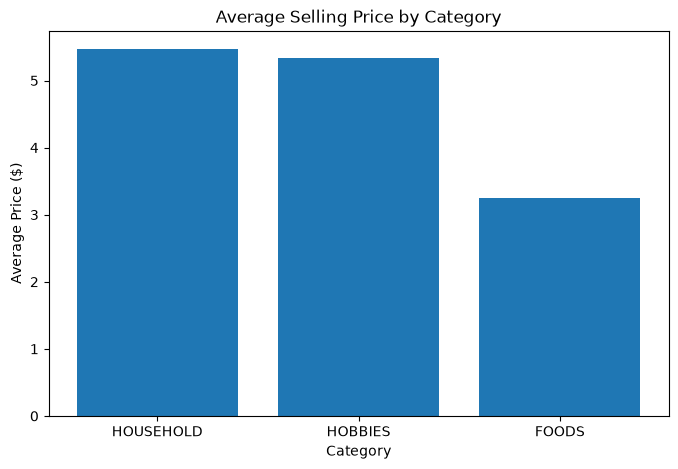

In [35]:
plt.figure(figsize=(8,5))

plt.bar(
    avg_price_category.index,
    avg_price_category.values
)

plt.title("Average Selling Price by Category")

plt.xlabel("Category")

plt.ylabel("Average Price ($)")

plt.show()

### Observation

Selling prices vary considerably across products and categories.

Understanding historical pricing behavior will be important later when developing the pricing simulation and revenue optimization components of the project.

# Time-Series Analysis

Demand forecasting depends on understanding how sales change over time.

This section converts the Walmart M5 sales data into a daily time series and examines historical demand trends, seasonal patterns, and periods of unusually high or low sales.

In [36]:
daily_sales = sales.iloc[:, 6:-1].sum()

daily_sales.head()

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64

### Observation

Each value now represents the total number of units sold across all Walmart stores for a single day.

In [37]:
daily_sales = daily_sales.reset_index()

daily_sales.columns = ["d", "total_sales"]

daily_sales.head()

,d,total_sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


In [38]:
daily_sales = daily_sales.merge(
    calendar[["d", "date"]],
    on="d",
    how="left"
)

daily_sales.head()

,d,total_sales,date
0,d_1,32631,2011-01-29
1,d_2,31749,2011-01-30
2,d_3,23783,2011-01-31
3,d_4,25412,2011-02-01
4,d_5,19146,2011-02-02


In [39]:
daily_sales["date"] = pd.to_datetime(
    daily_sales["date"]
)

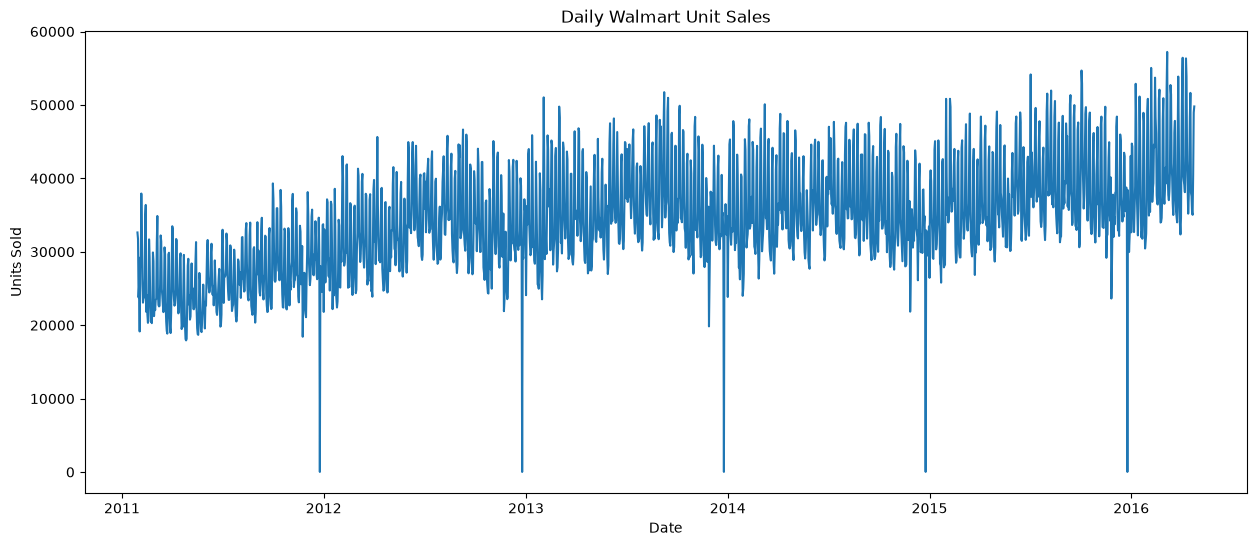

In [40]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"]
)

plt.title("Daily Walmart Unit Sales")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.show()

### Observation

Daily sales fluctuate considerably throughout the historical period, indicating that demand is influenced by seasonality, holidays, pricing, promotions, and other external factors.

These recurring patterns make the dataset well suited for time-series forecasting.

# Monthly Sales Trend

Aggregating sales by month helps identify seasonal demand patterns that may not be obvious in daily observations.

In [41]:
daily_sales["month"] = (
    daily_sales["date"]
    .dt.to_period("M")
)

In [42]:
monthly_sales = (
    daily_sales
    .groupby("month")["total_sales"]
    .sum()
)

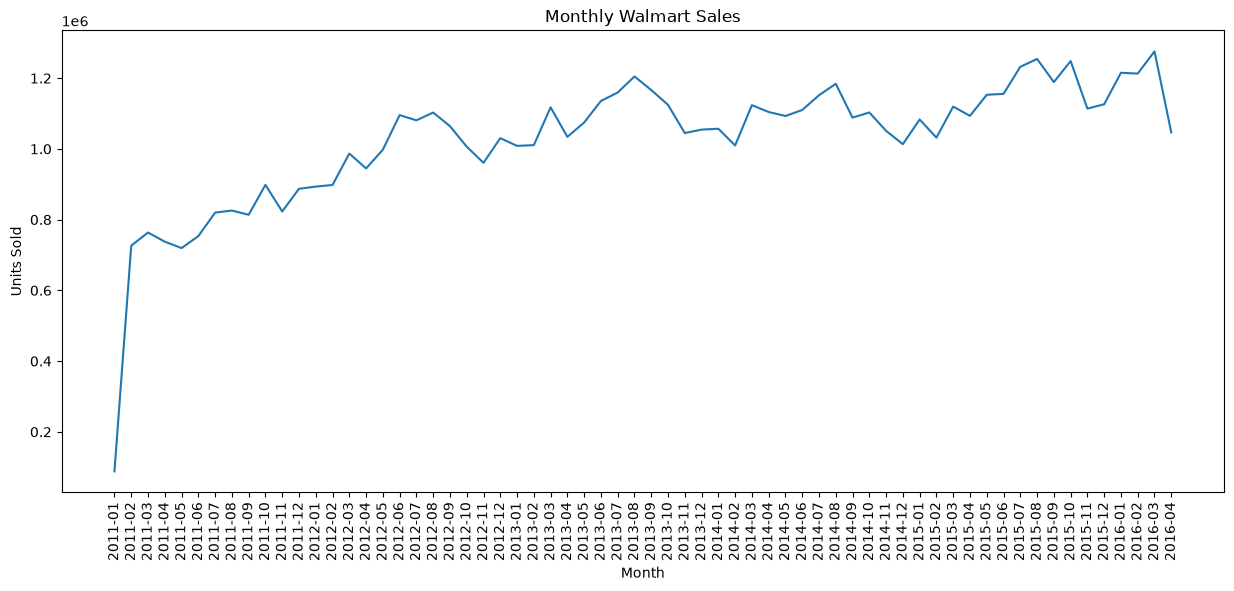

In [43]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title("Monthly Walmart Sales")

plt.xlabel("Month")

plt.ylabel("Units Sold")

plt.xticks(rotation=90)

plt.show()

### Observation

Monthly sales reveal recurring seasonal fluctuations throughout the dataset.

Recognizing these seasonal patterns will be important when engineering time-based features and selecting forecasting models such as Prophet or SARIMAX.

# Rolling Average

A rolling average reduces day-to-day noise and highlights longer-term demand trends.

In [44]:
daily_sales["7_day_avg"] = (
    daily_sales["total_sales"]
    .rolling(7)
    .mean()
)

daily_sales["30_day_avg"] = (
    daily_sales["total_sales"]
    .rolling(30)
    .mean()
)

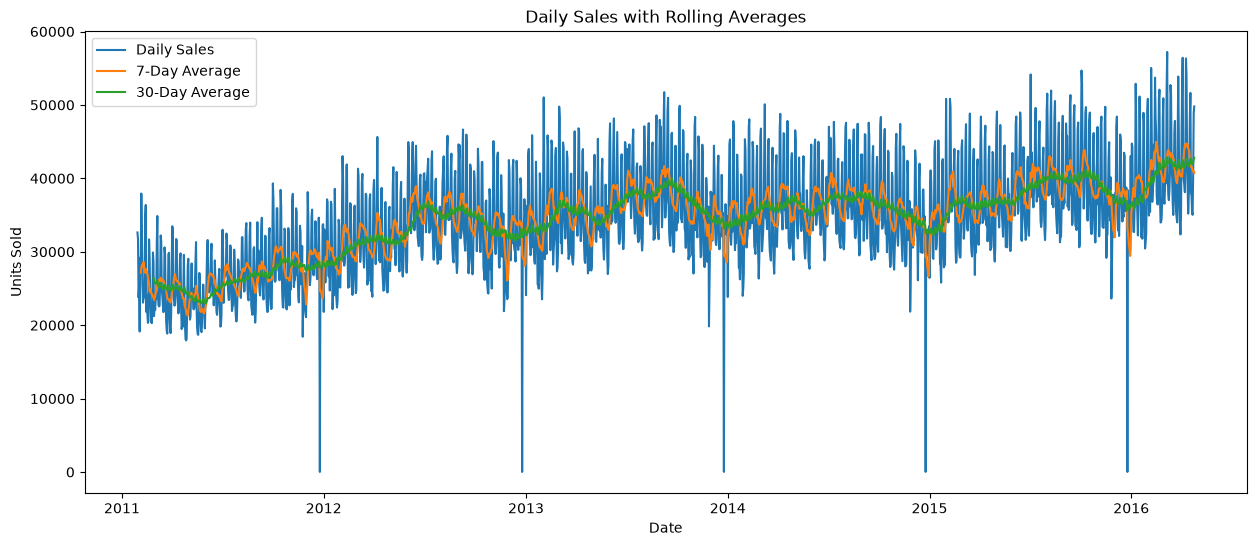

In [45]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"],
    label="Daily Sales"
)

plt.plot(
    daily_sales["date"],
    daily_sales["7_day_avg"],
    label="7-Day Average"
)

plt.plot(
    daily_sales["date"],
    daily_sales["30_day_avg"],
    label="30-Day Average"
)

plt.title("Daily Sales with Rolling Averages")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.show()

### Observation

Rolling averages smooth short-term fluctuations and reveal the underlying demand trend.

These moving averages will later become engineered features used by machine learning models.

# Holiday Impact Analysis

Retail demand often changes around holidays and special events.

This analysis compares average sales on event days versus non-event days.

In [46]:
daily_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   d            1913 non-null   str           
 1   total_sales  1913 non-null   int64         
 2   date         1913 non-null   datetime64[us]
 3   month        1913 non-null   period[M]     
 4   7_day_avg    1907 non-null   float64       
 5   30_day_avg   1884 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(1), period[M](1), str(1)
memory usage: 89.8 KB


In [47]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


In [48]:
calendar["date"] = pd.to_datetime(calendar["date"])

In [49]:
holiday_sales = daily_sales.merge(
    calendar[
        ["date",
         "event_name_1",
         "event_type_1"]
    ],
    on="date",
    how="left"
)

In [50]:
holiday_sales["holiday"] = (
    holiday_sales["event_name_1"]
    .notna()
)

In [51]:
holiday_summary = (

    holiday_sales

    .groupby("holiday")["total_sales"]

    .mean()

)

holiday_summary

holiday
False    34489.207504
True     32655.149351
Name: total_sales, dtype: float64

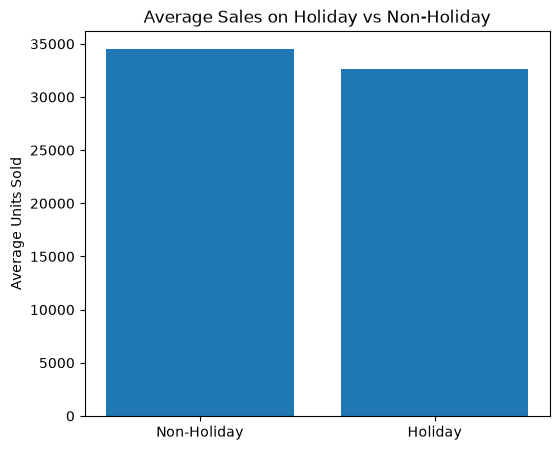

In [52]:
plt.figure(figsize=(6,5))

plt.bar(

    ["Non-Holiday", "Holiday"],

    holiday_summary.values

)

plt.title("Average Sales on Holiday vs Non-Holiday")

plt.ylabel("Average Units Sold")

plt.show()

### Observation

Average demand differs between holiday and non-holiday periods.

Holiday indicators are therefore likely to provide useful predictive information and will be included as engineered features in the forecasting models.

# Executive Summary

The business analysis identified several important characteristics of the Walmart M5 dataset:

- Sales are distributed across 10 Walmart stores in three states.
- Products are organized into three categories and seven departments.
- Historical demand exhibits strong temporal variation.
- Daily and monthly sales display recurring seasonal patterns.
- Selling prices vary across products and categories.
- Holiday periods influence customer demand.
- The dataset is well suited for demand forecasting and pricing optimization.

These findings provide the business foundation for the next phase of the project, which will focus on designing the PostgreSQL data warehouse and building the ETL pipeline.